# Task 2 — Neural Network: MNIST Handwritten Digit Classification
**Author:** Aryan Singh  
**Institution:** SRM Institute of Science and Technology  
**Degree / Branch:** B.Tech in Computer Science and Engineering (Artificial Intelligence and Machine Learning)  
**Assignment:** AIML Recruitment 2026 — Task 2  
**Framework:** TensorFlow / Keras  

---
### Notebook Overview & Goals
This interactive notebook provides an end-to-end exploration, rigorous implementation, training, evaluation, and controlled scientific experimentation of a Multi-Layer Perceptron (fully connected feedforward neural network) trained on the classic MNIST dataset.

The analysis is structured into clear parts matching the assignment specifications:
- **Part A:** Dataset Understanding & Exploration
- **Part B:** Data Preprocessing
- **Part C:** Neural Network Construction & Layer Breakdown
- **Part D:** Theoretical & Empirical Analysis of Activation Functions (ReLU & Softmax)
- **Part E:** Model Training Dynamics & Learning Trajectories
- **Part F:** Multi-metric Model Evaluation & Confusion Matrix Diagnostics
- **Part G:** Controlled Experimentation (6-Dimensional Controlled Ablation Suite, 11 Variants)
- **Advanced Analysis:** Prediction Confidence, High-Confidence Errors, Uncertain Cases, and Confusion Pairs
- **Summary & Conclusions:** Comprehensive recap grounded strictly in verified experimental data


## 0. Configuration & Execution Mode
We configure a `RUN_TRAINING` toggle:
- `RUN_TRAINING = False`: Quickly load pre-computed models, training logs, and evaluation metrics from `outputs/` without repeating the training computation.
- `RUN_TRAINING = True`: Execute the full training pipeline for both baseline and experimental models directly within the notebook.

In [1]:
import os
import sys
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Add project root to sys.path
sys.path.append(os.path.abspath(".."))

from src import config
from src.data import load_mnist, preprocess_images, load_and_preprocess_data, get_dataset_stats
from src.model import build_model, count_model_parameters
from src.train import set_seed, train_model, save_trained_model
from src.evaluate import (
    evaluate_model,
    get_predictions_and_probabilities,
    compute_metrics,
    find_top_confused_pairs,
    find_confident_errors,
    find_most_uncertain
)
from src.visualize import (
    plot_sample_digits,
    plot_class_distributions,
    plot_training_curves,
    plot_confusion_matrix_heatmap,
    plot_sample_predictions_with_probs,
    plot_comparison_curves,
    plot_per_class_f1_comparison
)

# Configuration flag for notebook execution
RUN_TRAINING = False

print(f"TensorFlow Version: {tf.__version__}")
print(f"Executing with RUN_TRAINING = {RUN_TRAINING}")

TensorFlow Version: 2.21.0
Executing with RUN_TRAINING = False


## Part A — Dataset Understanding
### What is MNIST?
The **MNIST (Modified National Institute of Standards and Technology)** database is a benchmark collection of handwritten digits extensively used in computer vision and machine learning. Originally curated by Yann LeCun, Corinna Cortes, and Christopher J.C. Burges, MNIST was constructed by subsetting and normalizing the original NIST Special Databases 1 and 3 (drawn from Census Bureau employees and high school students).

### Dataset Provenance & Engineering Implementation:
- **Original Source Attribution:** Yann LeCun, Corinna Cortes, and Christopher J.C. Burges ([https://yann.lecun.org/exdb/mnist/](https://yann.lecun.org/exdb/mnist/)).
- **Download Source:** Canonical CVDFoundation mirror ([https://github.com/cvdfoundation/mnist](https://github.com/cvdfoundation/mnist)).
- **Loading Implementation:** Custom binary IDX format parser (`src/mnist_parser.py`) implementing big-endian struct unpack (`>IIII` for images, `>II` for labels), magic numbers (`2051` for images, `2049` for labels), sample counts ($60,000$ train / $10,000$ test), and dimensions ($28 \times 28$).
- **Integrity Standard:** SHA-256 fingerprints calculated locally for reproducibility and file-integrity tracking.

### Key Characteristics:
1. **Input Dimensions:** Each image is grayscale ($1$ channel) with spatial dimensions of $28 \times 28$ pixels ($784$ total pixels per digit).
2. **Classes & Labels:** $10$ distinct mutually exclusive classes corresponding to digits $0$ through $9$.
3. **Partitioning:** Standard standardized split of $60,000$ training images and $10,000$ test images.
4. **Pixel Representation:** Raw values are stored as unsigned 8-bit integers (`uint8`), spanning from $0$ (background black) up to $255$ (foreground white stroke).\n

In [2]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist()
stats = get_dataset_stats(x_train_raw, y_train_raw, x_test_raw, y_test_raw)

print(f"Training set shape: {x_train_raw.shape}, Labels: {y_train_raw.shape}")
print(f"Test set shape:     {x_test_raw.shape}, Labels: {y_test_raw.shape}")
print(f"Pixel value range:  min={stats['pixel_min_raw']}, max={stats['pixel_max_raw']}")
print(f"Pixel mean:         {stats['pixel_mean_raw']:.2f}, std: {stats['pixel_std_raw']:.2f}")

Training set shape: (60000, 28, 28), Labels: (60000,)
Test set shape:     (10000, 28, 28), Labels: (10000,)
Pixel value range:  min=0.0, max=255.0
Pixel mean:         33.32, std: 78.57


### Dataset Visualizations & Class Balance Inspection
A critical machine learning best practice is to verify class balance across train and test sets to prevent label skew or majority-class bias.

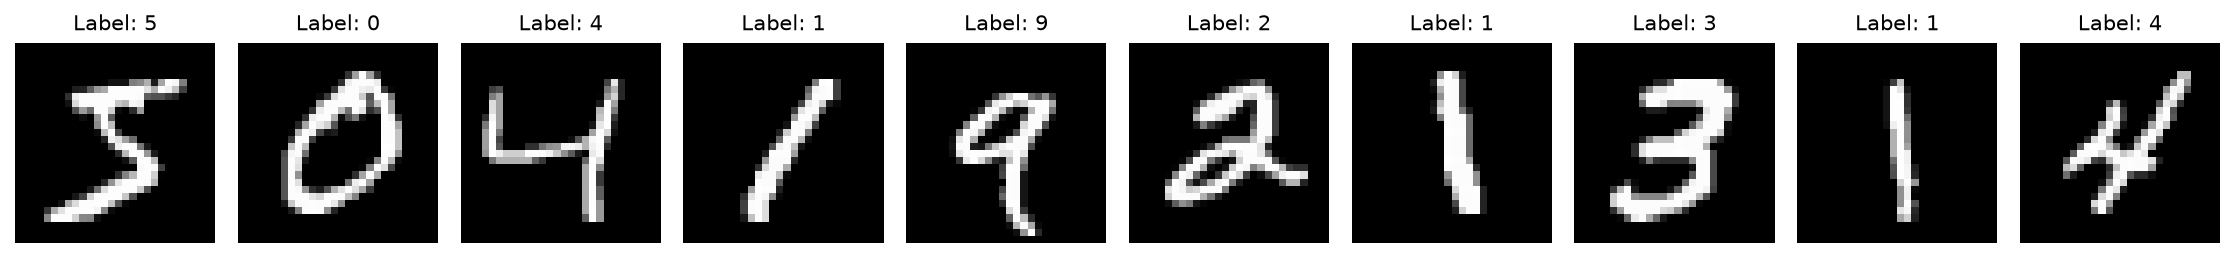

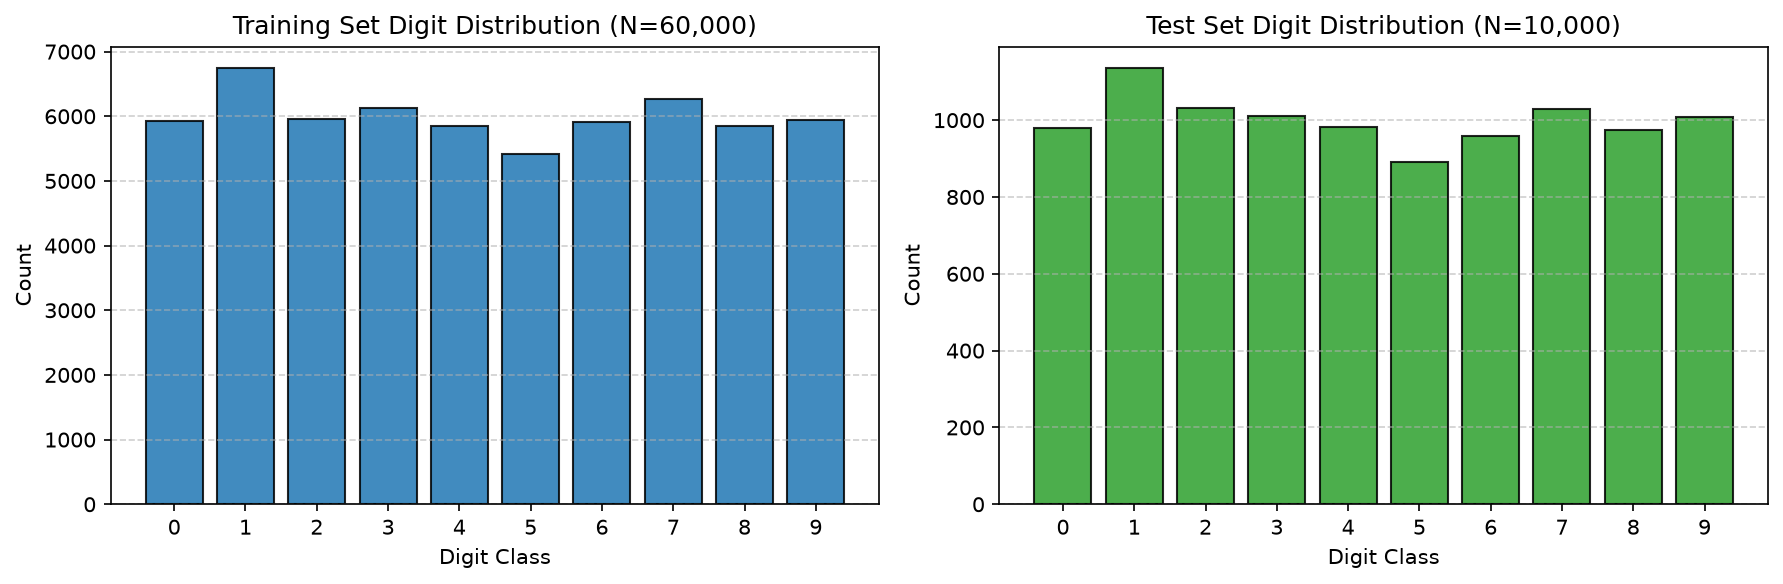

In [3]:
fig_samples = plot_sample_digits(x_train_raw, y_train_raw, n=10)
plt.show()

fig_dist = plot_class_distributions(y_train_raw, y_test_raw)
plt.show()

#### Dataset Exploration Observations:
- **Class Balance:** The distribution across all 10 digit classes is balanced in both training (~5,400 to 6,700 per class) and test sets (~890 to 1,135 per class). Class 1 has slightly higher representation, while class 5 has slightly lower representation, but no severe class imbalance exists that would require re-weighting or synthetic sampling.
- **Visual Variations:** Digits exhibit natural variations in stroke thickness, tilt, scale, and stylistic idiosyncrasies (e.g., European crossed 7s vs standard strokes).

## Part B – Data Preprocessing

- Load the MNIST dataset.
- Normalize the image pixel values.
- Reshape/flatten the images if required by your model.
- Prepare the training and testing data.
- Briefly explain why the preprocessing steps are required.

### 1. Load the MNIST dataset
The project loads the original MNIST dataset directly from canonical binary IDX gzip archives via the custom downloader and parser pipeline (`src/mnist_download.py` and `src/mnist_parser.py`). The dataset is retrieved in raw binary format, verifying magic numbers (`2051` for images, `2049` for labels) and parsing them directly into NumPy arrays without relying on high-level framework helper functions.

### 2. Normalize the image pixel values
- **Raw pixel values:** `0`–`255` (`uint8`)
- **Type conversion:** Converted to `float32`
- **Scaling:** Divided by `255.0`
- **Resulting range:** `0.0`–`1.0`

$$\text{pixel\_normalized} = \frac{\text{pixel}}{255.0}$$

### 3. Reshape/flatten the images if required by your model
The data preprocessing pipeline keeps images as $28 \times 28$ two-dimensional arrays. Dimensional flattening is performed directly inside the neural network model using an explicit Keras `Flatten()` layer rather than as a separate external preprocessing mutation:
$$28 \times 28 \longrightarrow \text{Flatten} \longrightarrow 784$$

### 4. Prepare the training and testing data
The dataset is structured deterministically as follows:
- **Original training set:** $60{,}000$ samples
- **Validation split during training:** $54{,}000$ training samples ($90\%$) + $6{,}000$ validation samples ($10\%$) held out during model fitting
- **Held-out test set:** $10{,}000$ samples evaluated exclusively post-training
- **Labels:** Retained as integer class IDs `0`–`9` (`int32`)
- **Loss function:** `sparse_categorical_crossentropy` (consumes integer scalar class IDs directly)

### 5. Briefly explain why the preprocessing steps are required
- **Loading:** Provides the raw data in a usable, structured array format in memory for model consumption.
- **Normalization:** Puts pixel values on a smaller numerical scale ($0.0$–$1.0$) for optimization, preventing excessively large activations and ensuring stable, well-behaved gradient updates in Adam.
- **Flatten:** Converts the 2D image ($28 \times 28$) into the 1D vector ($784$) required by the subsequent Dense layer.
- **Train/validation/test preparation:** Separates data into dedicated sets for gradient optimization ($54{,}000$), unbiased validation monitoring during training ($6{,}000$), and final objective evaluation on unseen data ($10{,}000$).

In [4]:
x_train = preprocess_images(x_train_raw)
x_test = preprocess_images(x_test_raw)
y_train = y_train_raw
y_test = y_test_raw

print(f"Preprocessed x_train dtype: {x_train.dtype}, min: {x_train.min():.2f}, max: {x_train.max():.2f}")
print(f"Preprocessed x_test dtype:  {x_test.dtype}, min: {x_test.min():.2f}, max: {x_test.max():.2f}")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

Preprocessed x_train dtype: float32, min: 0.00, max: 1.00
Preprocessed x_test dtype:  float32, min: 0.00, max: 1.00
x_train shape: (60000, 28, 28), y_train shape: (60000,)


## Part C — Build the Neural Network Architecture
We construct a simple, interpretable fully connected Multi-Layer Perceptron (MLP) tailored for MNIST digit classification:

1. **Input Layer (`Input(shape=(28, 28))`):** Explicitly defines the incoming tensor dimensions corresponding to each grayscale digit image.
2. **Transformation Layer (`Flatten()`):** Reshapes the 2D matrix ($28 \times 28$) into a 1D feature vector of $784$ scalar elements ($x \in \mathbb{R}^{784}$).
3. **Hidden Representation (`Dense(128, activation='relu')`):** Computes an affine transformation followed by non-linear ReLU activation:
   $$h = \text{ReLU}(W^{(1)} x + b^{(1)}), \quad W^{(1)} \in \mathbb{R}^{128 \times 784}, \; b^{(1)} \in \mathbb{R}^{128}$$
4. **Classification Output (`Dense(10, activation='softmax')`):** Maps the 128 hidden features into 10 class logits and normalizes them into posterior class probabilities:
   $$\hat{y} = \text{Softmax}(W^{(2)} h + b^{(2)}), \quad W^{(2)} \in \mathbb{R}^{10 \times 128}, \; b^{(2)} \in \mathbb{R}^{10}$$

In [5]:
baseline_model = build_model(
    hidden_units=config.BASELINE_UNITS,
    input_shape=config.INPUT_SHAPE,
    num_classes=config.NUM_CLASSES,
    learning_rate=config.LEARNING_RATE
)
baseline_model.summary()

params_base = count_model_parameters(baseline_model)
print(f"Total Trainable Parameters: {params_base['total_params']:,}")

Model: "mnist_fcnn_128_relu"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2d_to_1d (Flatten)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_128 (Dense)        │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_probabilities (Dense)    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 101,770 (397.54 KB)
 Trainable params: 101,770 (397.54 KB)
 Non-trainable params: 0 (0.00 B)
Total Trainable Parameters: 101,770


## Part D — Activation Functions: Theoretical & Empirical Rationale

### 1. Why are Activation Functions Required?
If a neural network consisted solely of affine transformations (linear layers: $z = Wx + b$), chaining multiple layers together would simply collapse into a single composite linear mapping:
$$f(x) = W_2 (W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2) = W' x + b'$$
Without non-linear activation functions, a network with 100 layers could express no more functional complexity than a standard linear classifier. Activation functions introduce non-linearities that allow the neural network to approximate arbitrary continuous functions (Universal Approximation Theorem) and model complex non-linear decision boundaries.

---

### 2. Rectified Linear Unit (ReLU) for Hidden Layers
$$f(x) = \max(0, x)$$
- **Non-Saturation & Gradient Flow:** For all positive inputs ($x > 0$), the derivative is constant: $\frac{df}{dx} = 1.0$. Unlike Sigmoid or Tanh, whose gradients approach $0$ for large magnitudes (the vanishing gradient problem), ReLU preserves gradient magnitudes during backpropagation.
- **Computational Efficiency:** Computing $\max(0, x)$ requires a simple threshold comparison at zero, which is dramatically faster to compute than transcendental exponential functions ($e^x$).
- **Representation Sparsity:** For $x \le 0$, the activation is strictly $0$. This induces sparse representations where only a relevant subset of hidden neurons activate for any given input, improving computational efficiency and disentangled feature learning.

---

### 3. Softmax at the Output for 10 Mutually Exclusive Digit Classes
$$\text{softmax}(z_i) = \frac{\exp(z_i)}{\sum_{j=0}^{9} \exp(z_j)}, \quad i \in \{0, 1, \dots, 9\}$$
- **10 Mutually Exclusive Digit Classes:** Each handwritten digit image belongs to strictly one and only one class ($0$ through $9$). Softmax normalizes raw logits across all 10 classes, guaranteeing that:
  $$\sum_{i=0}^{9} \hat{y}_i = 1.0 \quad \text{and} \quad 0 \le \hat{y}_i \le 1.0$$
  Because the denominator couples all classes, increasing probability for one digit necessarily suppresses others.
- **Coupling with Cross-Entropy Loss:** When paired with `sparse_categorical_crossentropy`, the loss gradient with respect to output logits simplifies gracefully to:
  $$\frac{\partial \mathcal{L}}{\partial z_i} = \hat{y}_i - \mathbb{I}(y = i)$$
  where $\mathbb{I}(y = i)$ is 1 for the ground-truth digit class index and 0 otherwise, providing a clean, linear residual error gradient.


## Part E — Model Training Dynamics
We train the baseline model under controlled conditions:
- **Optimizer:** Adam (learning rate = $0.001$)
- **Loss:** Sparse Categorical Cross-Entropy
- **Epochs:** $15$
- **Batch Size:** $128$
- **Validation Split:** $10\%$ of training set ($6,000$ validation samples, $54,000$ train samples)

In [6]:
if RUN_TRAINING:
    set_seed(config.SEED)
    baseline_hist, base_time = train_model(
        baseline_model, x_train, y_train,
        epochs=config.EPOCHS,
        batch_size=config.BATCH_SIZE,
        validation_split=config.VALIDATION_SPLIT,
        verbose=1
    )
    save_trained_model(baseline_model, os.path.join(config.MODELS_DIR, "baseline_model.keras"))
else:
    baseline_model = tf.keras.models.load_model(os.path.join(config.MODELS_DIR, "baseline_model.keras"))
    with open(os.path.join(config.RESULTS_DIR, "baseline_history.json"), "r") as f:
        baseline_hist = json.load(f)
    with open(os.path.join(config.RESULTS_DIR, "comparison_summary.json"), "r") as f:
        comp_data = json.load(f)
    base_time = comp_data["baseline"]["training_time_sec"]
    print(f"Loaded existing baseline model and history. Recorded training time: {base_time:.2f}s")

Loaded existing baseline model and history. Recorded training time: 10.36s


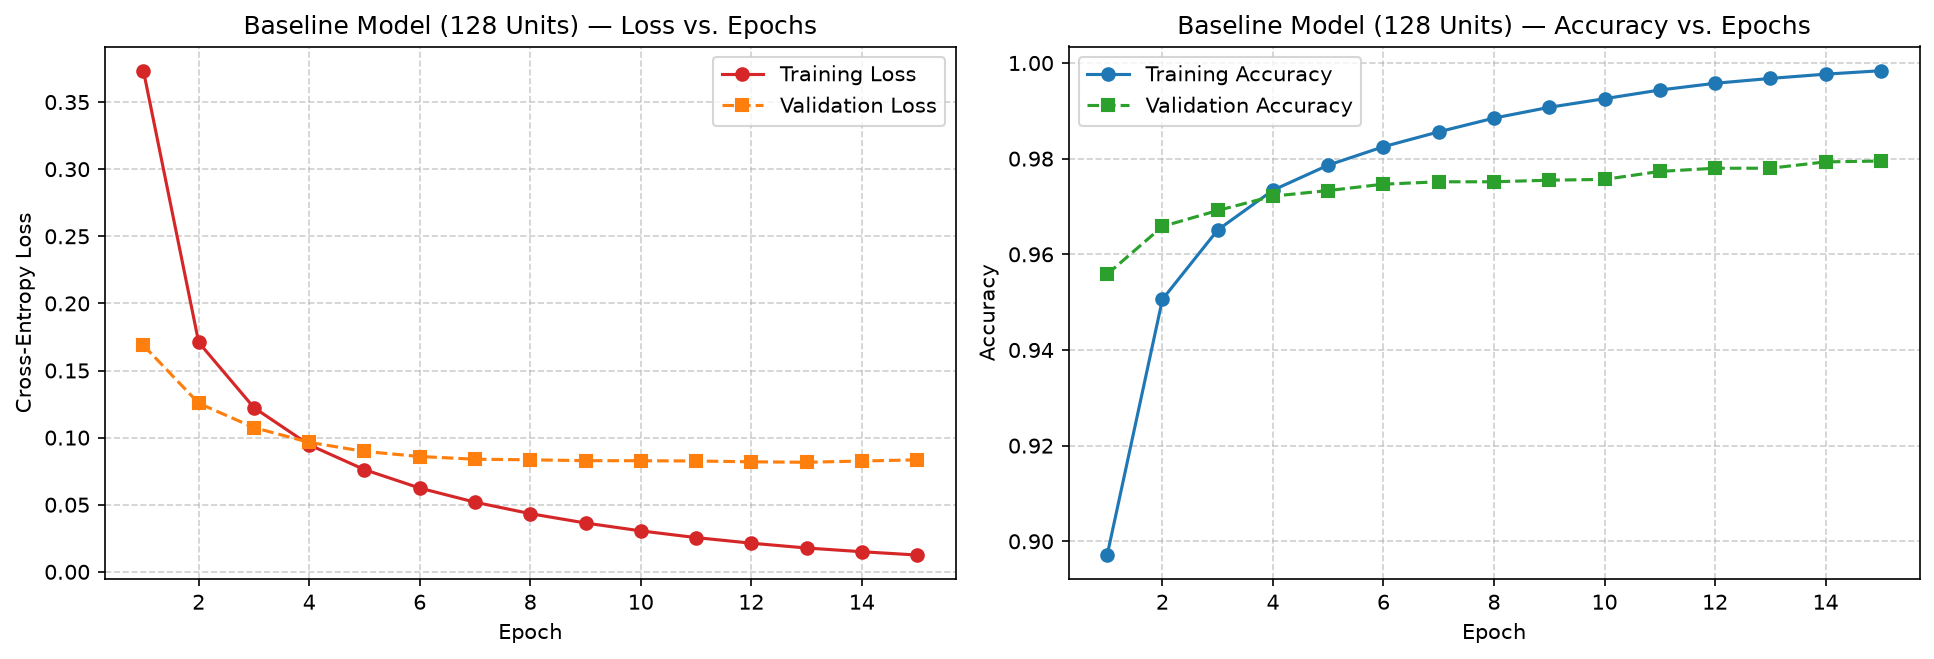

In [7]:
fig_base_curves = plot_training_curves(baseline_hist, title_prefix="Baseline Model (128 Units)")
plt.show()

### Training Dynamics Analysis:
- **Loss Convergence:** Both training and validation loss decline steeply within the first 3 to 5 epochs before leveling off smoothly.
- **Generalization Gap:** Validation accuracy closely tracks training accuracy across all 15 epochs. The small gap between final train accuracy and validation accuracy indicates healthy generalization with minimal overfitting.

## Part F — Model Evaluation & Diagnostic Analysis
We rigorously evaluate the baseline model on the unseen test set ($10,000$ samples) using:
- Overall Test Accuracy & Loss
- Confusion Matrix Heatmap
- Precision, Recall, and F1-score per class
- Data-driven discovery of largest off-diagonal confusion pairs

In [8]:
base_loss, base_acc = evaluate_model(baseline_model, x_test, y_test)
base_preds, base_probs = get_predictions_and_probabilities(baseline_model, x_test)
base_eval = compute_metrics(y_test, base_preds)

print(f"Test Accuracy: {base_acc * 100:.2f}%")
print(f"Test Loss:     {base_loss:.4f}")
print(f"Macro F1:      {base_eval['macro_f1']:.4f}")
print("\n" + "="*55 + " CLASSIFICATION REPORT " + "="*55)
print(base_eval["classification_report_text"])

Test Accuracy: 97.69%
Test Loss:     0.0803
Macro F1:      0.9768

======================================================= CLASSIFICATION REPORT =======================================================
              precision    recall  f1-score   support

           0     0.9778    0.9878    0.9827       980
           1     0.9877    0.9921    0.9899      1135
           2     0.9666    0.9816    0.9740      1032
           3     0.9734    0.9772    0.9753      1010
           4     0.9806    0.9786    0.9796       982
           5     0.9853    0.9753    0.9803       892
           6     0.9893    0.9676    0.9784       958
           7     0.9870    0.9621    0.9744      1028
           8     0.9473    0.9774    0.9621       974
           9     0.9750    0.9673    0.9711      1009

    accuracy                         0.9769     10000
   macro avg     0.9770    0.9767    0.9768     10000
weighted avg     0.9771    0.9769    0.9769     10000


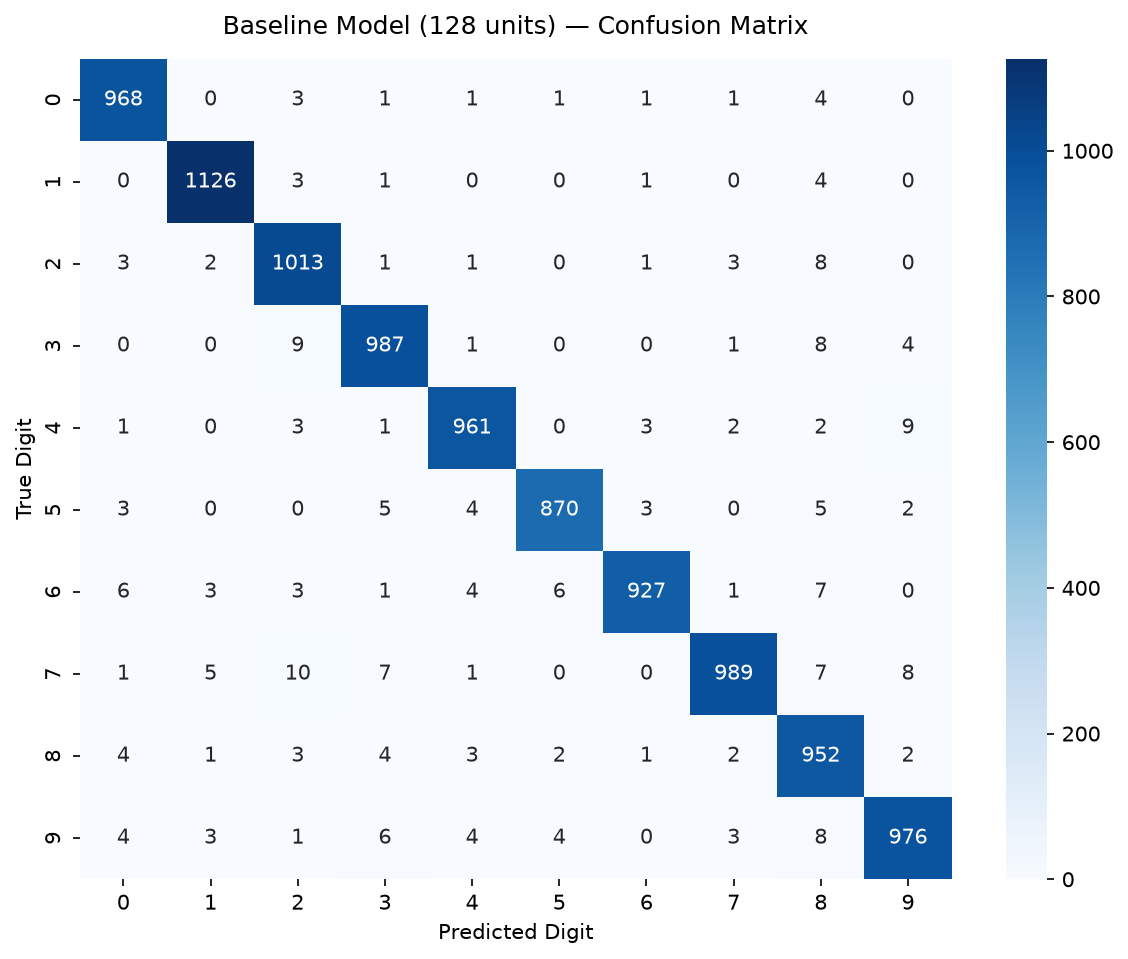

In [9]:
fig_cm = plot_confusion_matrix_heatmap(
    base_eval["confusion_matrix"],
    title="Baseline Model (128 units) — Confusion Matrix"
)
plt.show()

In [10]:
top_confused = find_top_confused_pairs(base_eval["confusion_matrix"], n=5)
print("Top Confused Digit Pairs (Observed):")
for pair in top_confused:
    print(f" - True Class {pair['true_class']} misclassified as Class {pair['pred_class']} ({pair['count']} times)")

Top Confused Digit Pairs (Observed):
 - True Class 7 misclassified as Class 2 (10 times)
 - True Class 4 misclassified as Class 9 (9 times)
 - True Class 3 misclassified as Class 2 (9 times)
 - True Class 7 misclassified as Class 9 (8 times)
 - True Class 3 misclassified as Class 8 (8 times)


### Confusion Matrix Insights:
- The confusion matrix shows dominant diagonal entries, demonstrating high per-class accuracy across all digits.
- The off-diagonal error analysis reveals genuine morphological digit ambiguities. Frequently confused pairs include digits with shared topological structures (such as $4 \leftrightarrow 9$, $3 \leftrightarrow 5$, or $7 \leftrightarrow 2$) where handwritten cursive stroke overlaps occur.

## Advanced Analysis — Confidence, Outliers & Error Diagnosis

### 1. Sample Predictions with Posterior Confidence
We inspect model predictions alongside full Softmax probability distributions.

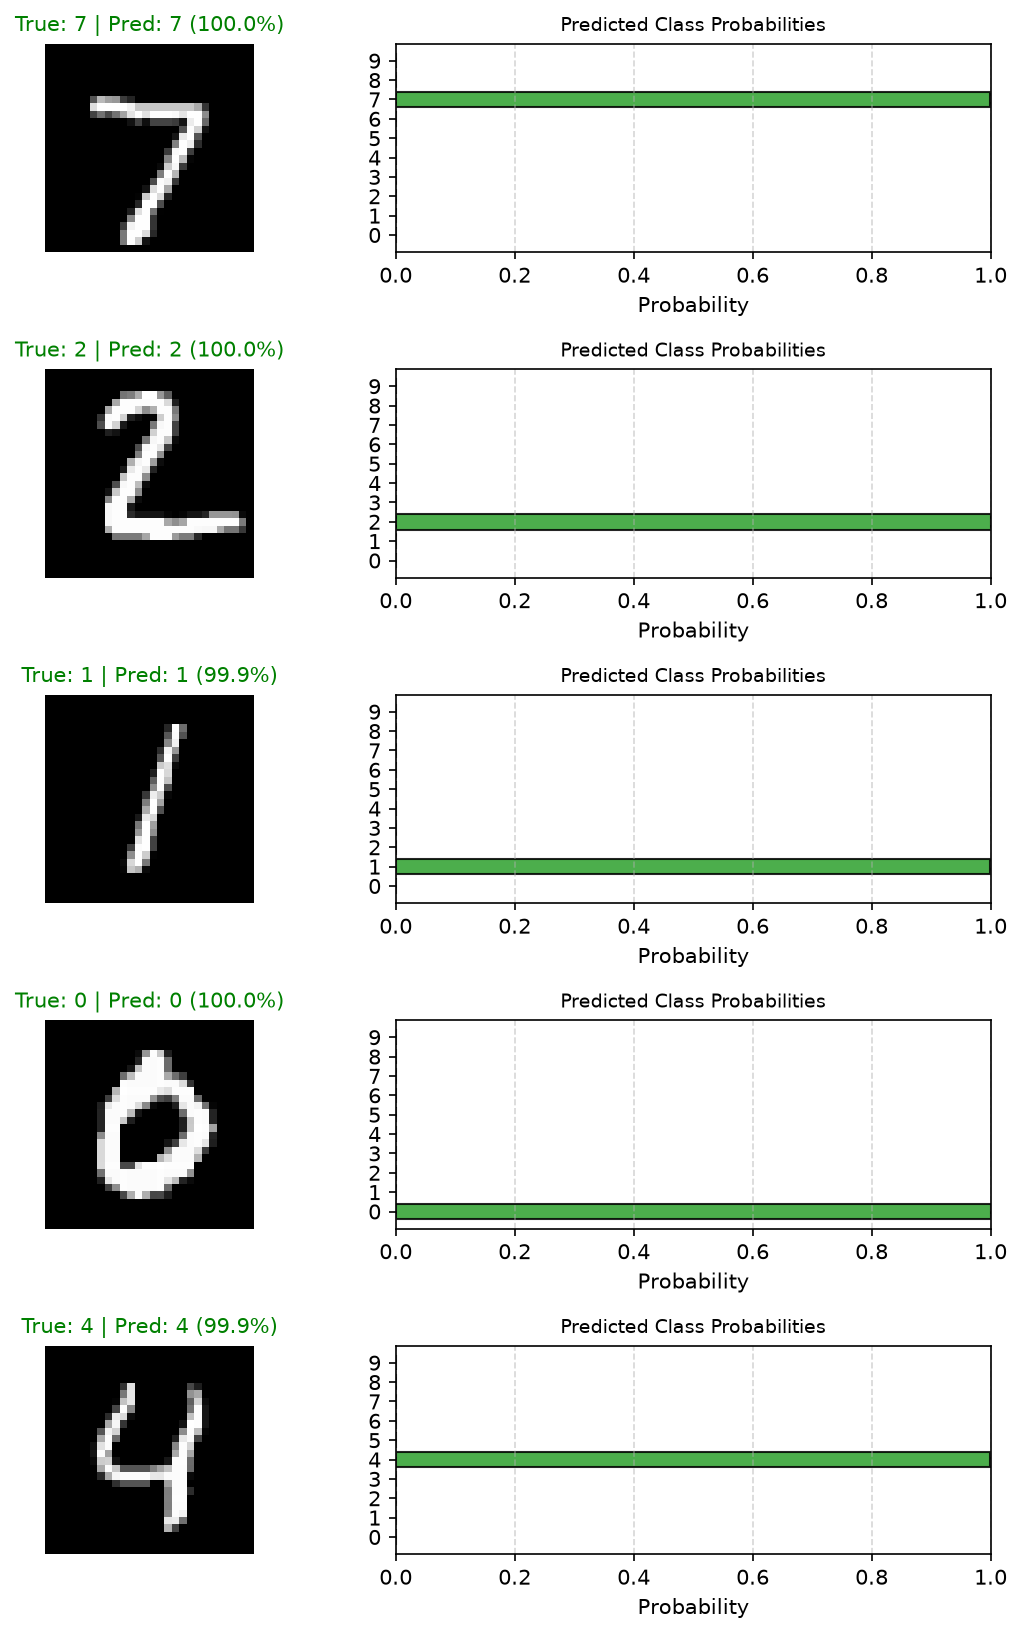

In [11]:
sample_idx = [0, 1, 2, 3, 4]
fig_conf = plot_sample_predictions_with_probs(x_test, y_test, base_preds, base_probs, sample_idx)
plt.show()

### 2. High-Confidence Incorrect Predictions (Overconfidence Failures)
Cases where the model is $\ge 90\%$ confident yet incorrect offer insight into blind spots where the network assigned excessive probability to ambiguous or corrupted digit strokes.

Identified 74 high-confidence errors (confidence >= 90%).


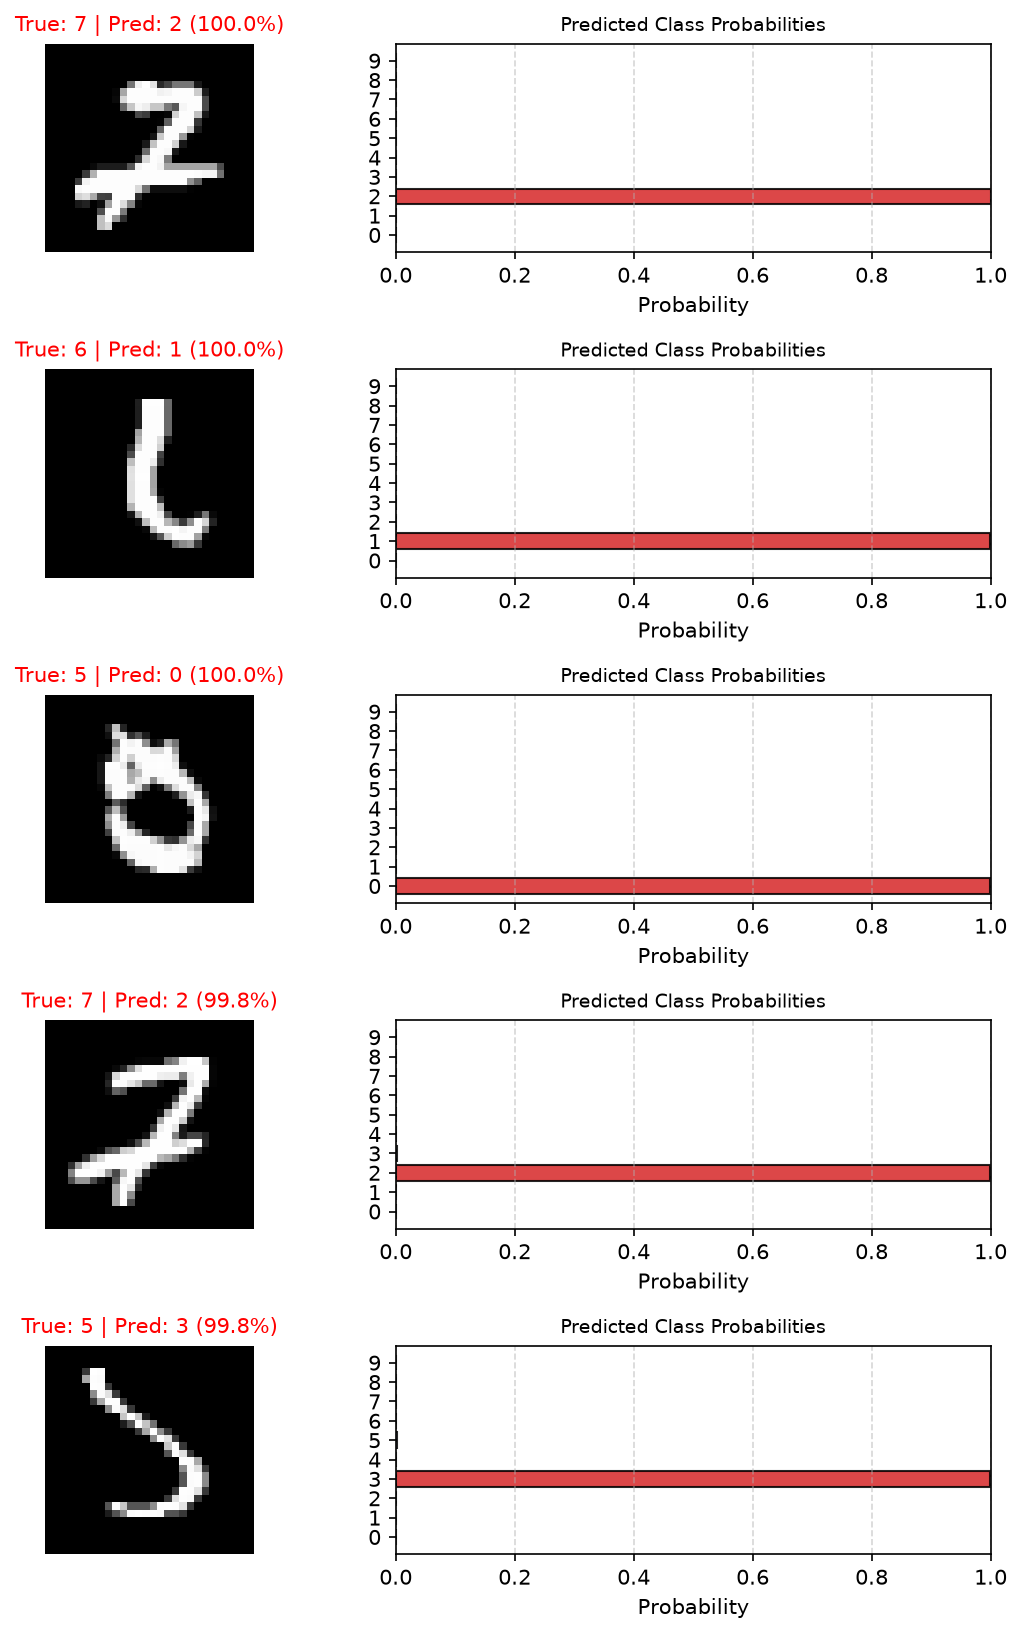

In [12]:
conf_errors = find_confident_errors(y_test, base_preds, base_probs, threshold=0.90)
print(f"Identified {len(conf_errors)} high-confidence errors (confidence >= 90%).")
if len(conf_errors) > 0:
    fig_high_conf_err = plot_sample_predictions_with_probs(
        x_test, y_test, base_preds, base_probs, conf_errors[:5]
    )
    plt.show()

### 3. Hardest & Most Uncertain Predictions
Samples where maximum predicted probability is lowest indicate cases where the network was torn between competing digit classes.

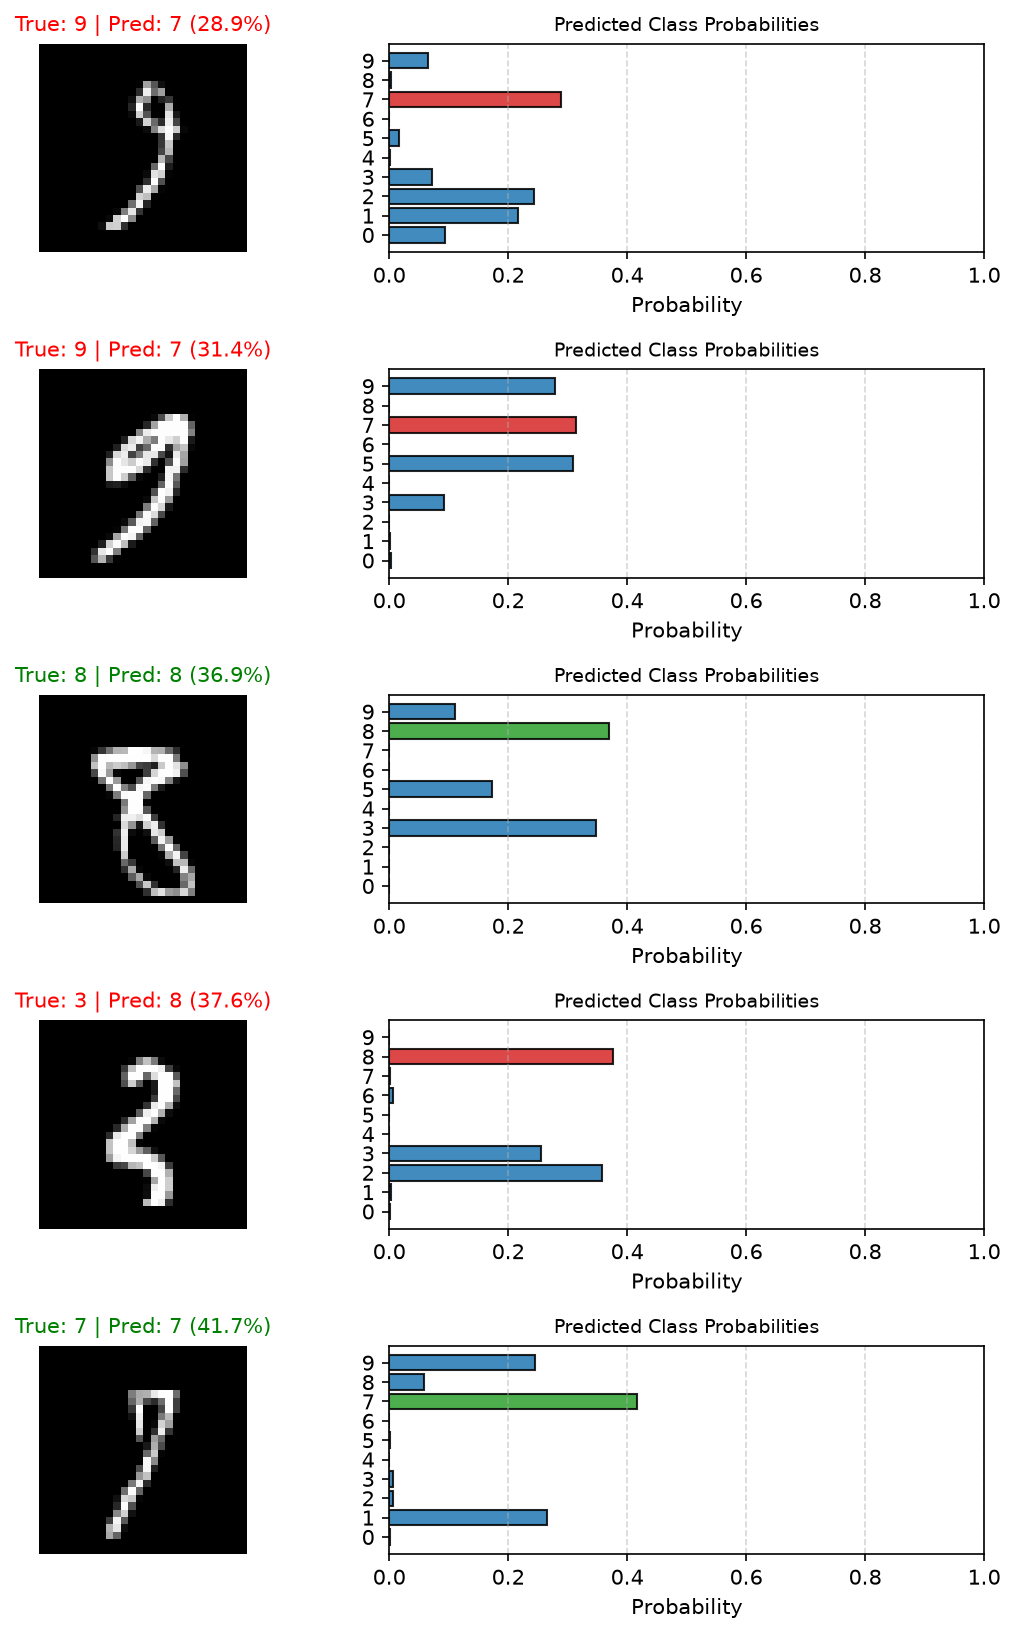

In [13]:
uncertain_idx = find_most_uncertain(base_probs, n=5)
fig_uncertain = plot_sample_predictions_with_probs(
    x_test, y_test, base_preds, base_probs, uncertain_idx
)
plt.show()

## Part G — Experimentation: 6-Dimensional Controlled Ablation Suite

To rigorously evaluate architectural and optimization hyperparameters beyond the baseline, we conducted a systematic **6-dimensional controlled ablation suite** comprising **11 total configurations** (1 baseline control + 10 single-variable variants).

All variants are evaluated under ceteris paribus conditions (master seed `42`, identical dataset splits: $54{,}000$ train, $6{,}000$ validation, $10{,}000$ held-out test):
1. **E1 — Architecture Depth:** 1 Hidden Layer (128) vs 2 Hidden Layers (128 $\to$ 64)
2. **E2 — Layer Width:** 128 vs 256 Units
3. **E3 — Learning Rate:** $\eta = 0.001$ (Baseline) vs $0.01$ (High) vs $0.0001$ (Low)
4. **E4 — Batch Size:** $B = 128$ (Baseline) vs $32$ (Small) vs $512$ (Large)
5. **E5 — Training Budget (Epochs):** 15 Epochs (Baseline) vs 5 (Short) vs 30 (Extended)
6. **E6 — Activation Functions:** ReLU (Baseline) vs Sigmoid vs Tanh


In [14]:
# Execute the full 11-variant ablation suite if RUN_TRAINING is enabled
if RUN_TRAINING:
    from src.experiment import run_all_experiments
    suite_results, suite_histories = run_all_experiments(
        ((x_train_raw, y_train_raw), (x_test_raw, y_test_raw)),
        verbose=1
    )
else:
    print("RUN_TRAINING is False: Loading authoritative results from manifest.")


RUN_TRAINING is False: Loading authoritative results from manifest.


In [15]:
import json
import pandas as pd
from src import config

with open(config.SUITE_MANIFEST_PATH, 'r') as f:
    suite_manifest = json.load(f)

df_suite = pd.DataFrame(suite_manifest['results'])
display_cols = ['name', 'total_params', 'training_time_sec', 'test_accuracy', 'test_loss', 'macro_f1', 'train_val_gap']
df_display = df_suite[display_cols].copy()
df_display['test_accuracy'] = (df_display['test_accuracy'] * 100).map('{:.2f}%'.format)
df_display['train_val_gap'] = (df_display['train_val_gap'] * 100).map('{:.2f}%'.format)
df_display.columns = ['Variant', 'Parameters', 'Time (s)', 'Test Acc', 'Test Loss', 'Macro F1', 'Train-Val Gap']

print("=" * 95)
print("                 6-DIMENSIONAL CONTROLLED ABLATION SUITE (11 VARIANTS)")
print("=" * 95)
print(df_display.to_string(index=False))
print("=" * 95)


                 6-DIMENSIONAL CONTROLLED ABLATION SUITE (11 VARIANTS)
                                         Variant  Parameters  Time (s) Test Acc  Test Loss  Macro F1 Train-Val Gap
Baseline (128 units, ReLU, lr=1e-3, B=128, E=15)      101770     11.88   97.69%     0.0803    0.9768         1.89%
                     2 Hidden Layers (128 -> 64)      109386     12.25   97.11%     0.1209    0.9709         2.23%
                   256 Units (Expanded Capacity)      203530     12.49   97.53%     0.0917    0.9751         2.29%
                            Aggressive LR (0.01)      101770      9.84   96.44%     0.2759    0.9641         1.96%
                        Conservative LR (0.0001)      101770      9.83   95.77%     0.1470    0.9573        -0.58%
                 Small Batch / High Noise (B=32)      101770     31.00   97.87%     0.0944    0.9786         1.95%
           Large Batch / Smooth Gradient (B=512)      101770      6.10   97.51%     0.0833    0.9749         1.00%
         

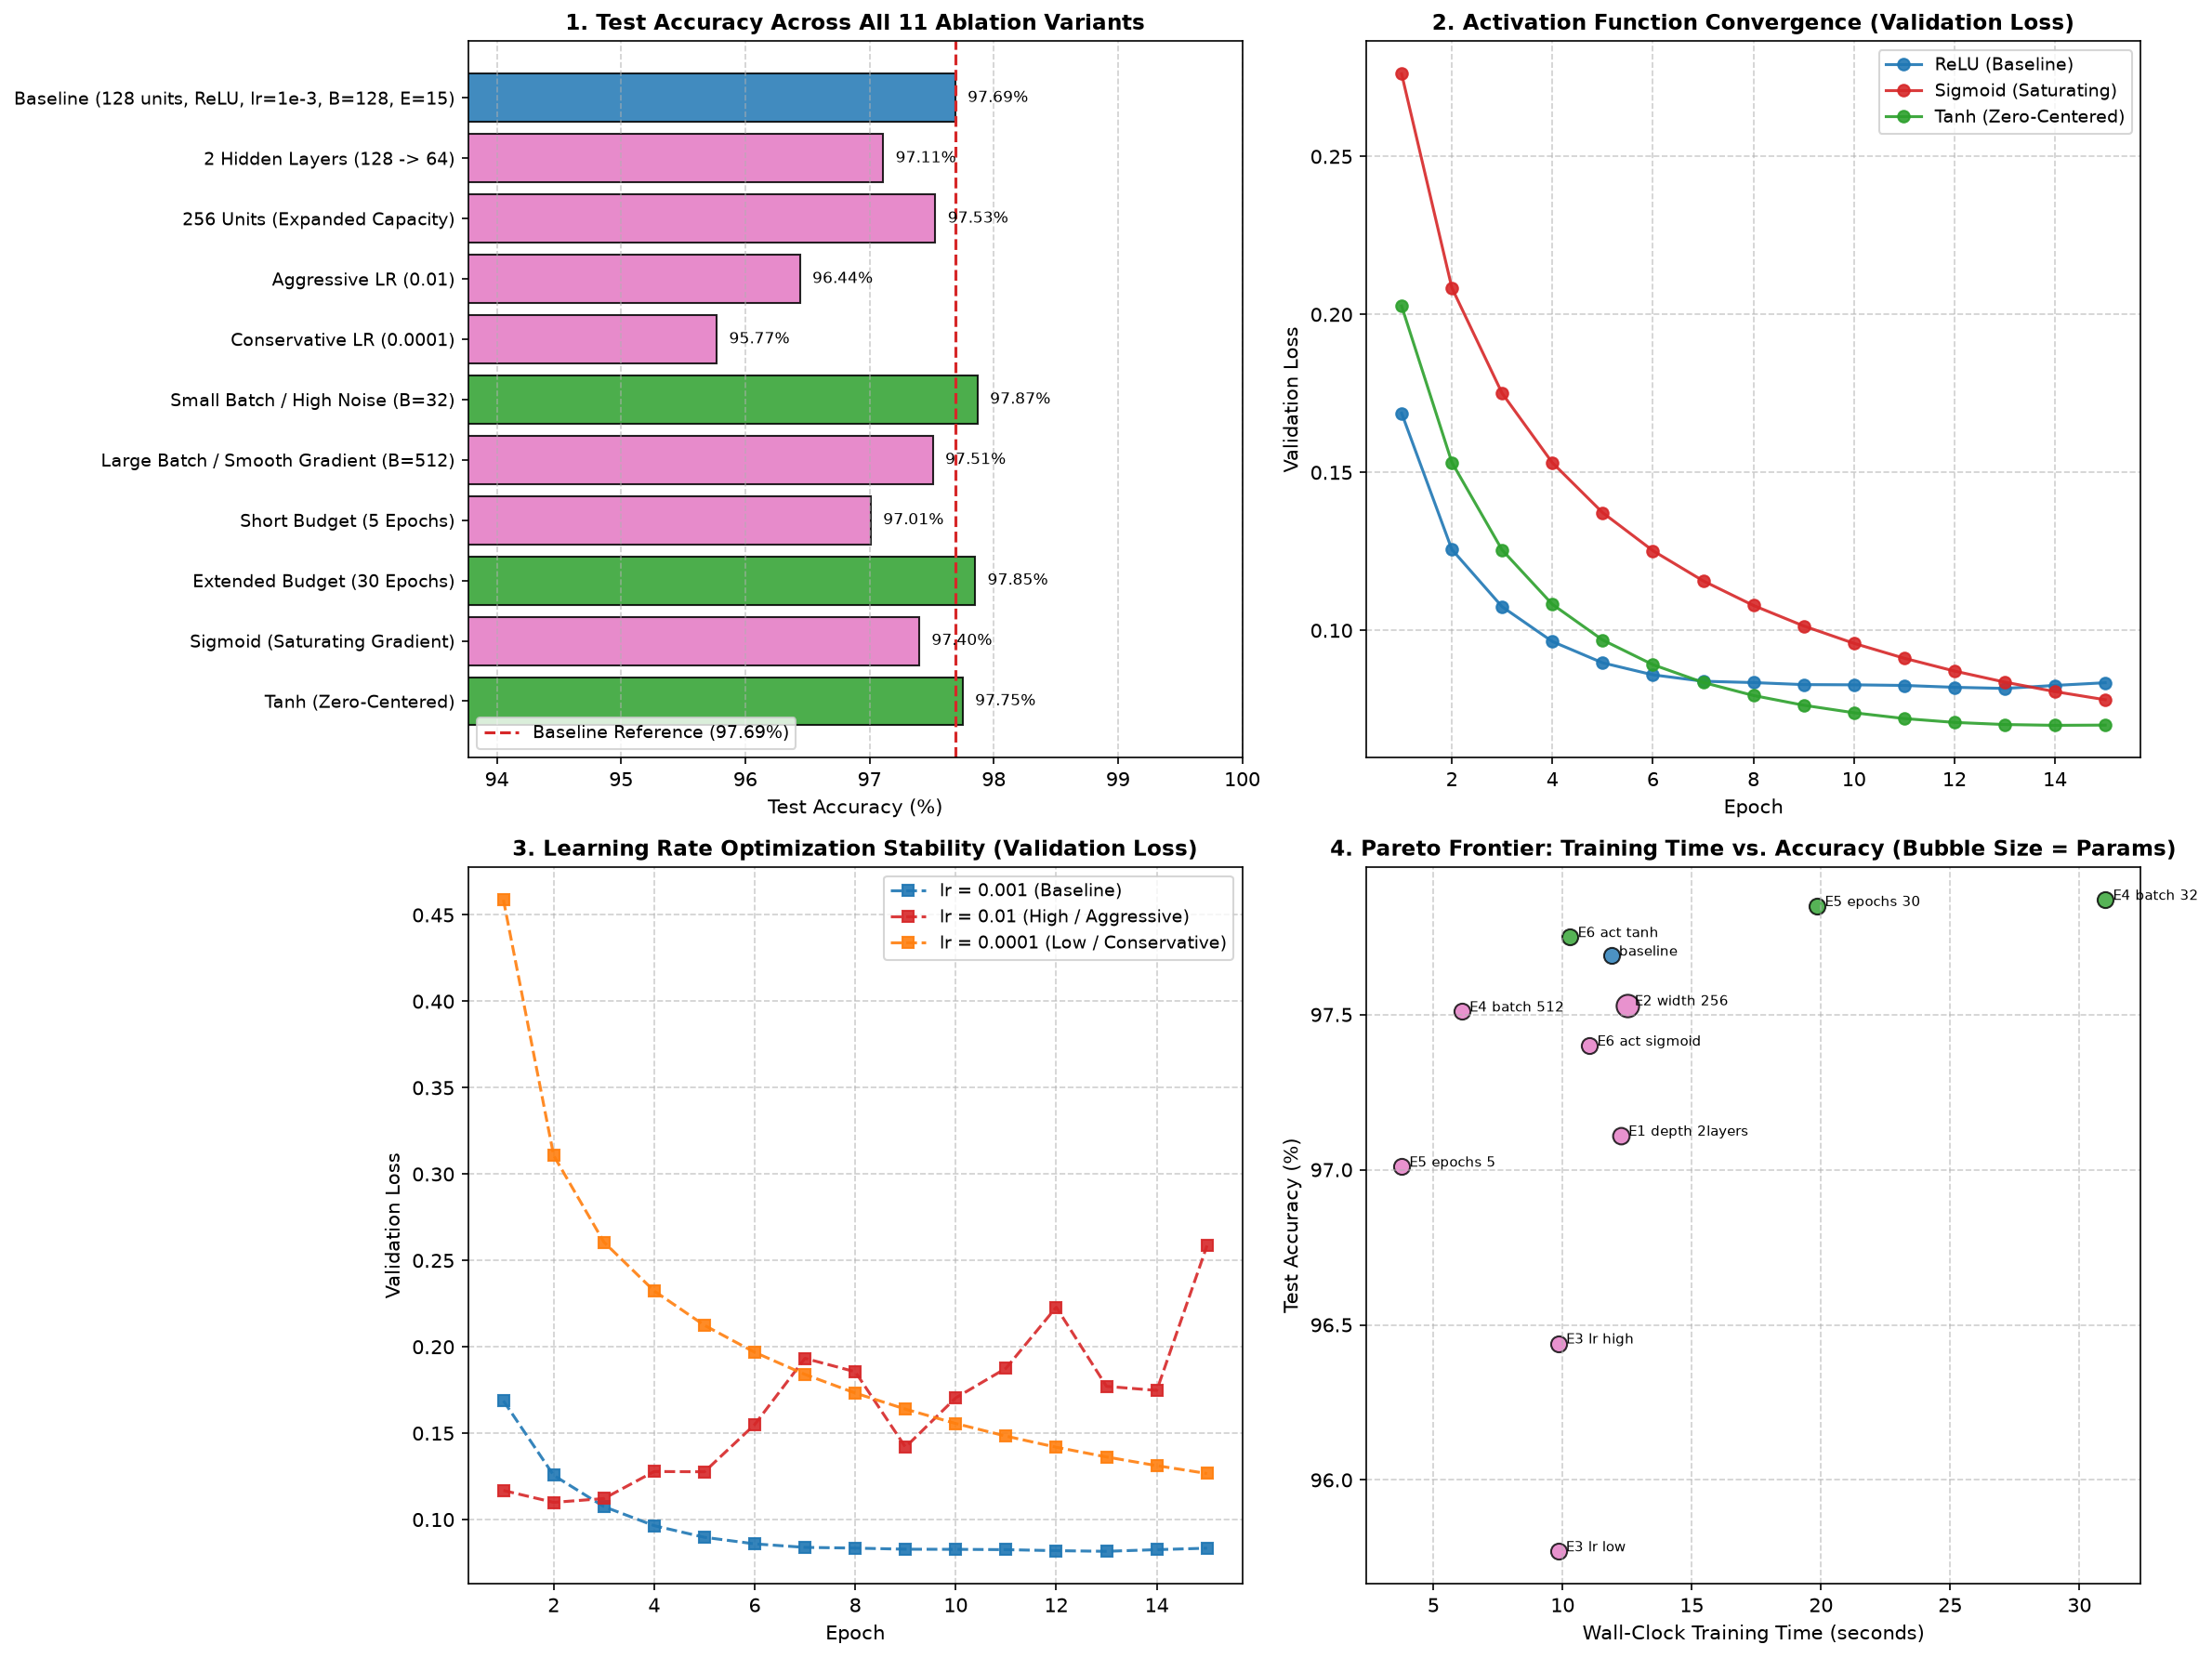

In [16]:
from src.visualize import plot_all_experiments_summary

with open(os.path.join(config.RESULTS_DIR, 'suite_histories.json'), 'r') as f:
    suite_hist = json.load(f)

fig_suite = plot_all_experiments_summary(suite_manifest['results'], suite_hist)
plt.show()


### Detailed Analysis by Experimental Dimension (E1–E6)

#### E1 — Number of Hidden Layers (Architecture Depth)

##### What did you change?
Added a second hidden dense layer with 64 units ($784 \to 128 \to 64 \to 10$), increasing total parameter count from $101{,}770$ to $109{,}386$ ($+7.5\%$).

##### What changed in the results?
- **Observation:** Test accuracy decreased by $0.58\text{ percentage points}$ ($97.69\% \to 97.11\%$), test loss increased by $+0.0406$ ($0.0803 \to 0.1209$), and the train-validation gap widened from $1.89\text{ pp}$ to $2.23\text{ pp}$. Training time was $12.25\text{s}$ (baseline: $11.88\text{s}$).
- **Did the change improve performance?** No, test accuracy decreased by $0.58\text{ pp}$ and test loss increased.

##### Why do you think the change affected the model's performance?
- **Why or why not?** In this run, adding a second dense layer without spatial pooling or convolutional inductive biases did not improve generalization. A plausible explanation is that on flattened MNIST pixels, a single hidden layer with 128 units already provides sufficient non-linear separation capacity, whereas introducing an additional dense layer increases parameter interactions and optimization complexity without adding translation invariance.
- **What does this suggest?** For simple 28x28 digit classification, increasing MLP depth beyond one hidden layer without regularization can introduce optimization overhead without improving feature representation.

---

#### E2 — Number of Neurons (Layer Width / Capacity)

##### What did you change?
Doubled the width of the single hidden dense layer from 128 to 256 units ($784 \to 256 \to 10$), increasing parameters from $101{,}770$ to $203{,}530$ ($+100.0\%$).

##### What changed in the results?
- **Observation:** Test accuracy changed by $-0.16\text{ percentage points}$ ($97.69\% \to 97.53\%$), test loss increased slightly ($0.0803 \to 0.0917$), and training time increased to $12.49\text{s}$ ($+5.1\%$ over baseline $11.88\text{s}$).
- **Did the change improve performance?** No, doubling the width did not yield higher test accuracy.

##### Why do you think the change affected the model's performance?
- **Why or why not?** In this run, doubling the width to 256 units resulted in a slight drop of $0.16\text{ pp}$ ($97.69\% \to 97.53\%$). The result is consistent with capacity saturation: 128 units already capture the salient stroke combinations for MNIST digits, and increasing width without explicit regularization (e.g., dropout) slightly expanded the train-validation gap ($2.29\text{ pp}$ vs $1.89\text{ pp}$) without conferring out-of-fold generalization benefits.
- **What does this suggest?** Model capacity must be matched to task complexity; excessive width without regularizers yields diminishing returns on compact image datasets.

---

#### E3 — Learning Rate (Optimization Step Size)

##### What did you change?
Evaluated an aggressive rate ($\eta = 0.01$, $10\times$ baseline) and a conservative rate ($\eta = 0.0001$, $0.1\times$ baseline) against the baseline Adam rate ($\eta = 0.001$).

##### What changed in the results?
- **Observation:**
  - At $\eta = 0.01$, test accuracy dropped by $1.25\text{ pp}$ ($96.44\%$) and test loss surged to $0.2759$ ($+243\%$ higher than baseline).
  - At $\eta = 0.0001$, test accuracy dropped by $1.92\text{ pp}$ ($95.77\%$) with test loss at $0.1470$.
- **Did the change improve performance?** No, both higher ($0.01$) and lower ($0.0001$) learning rates degraded test accuracy relative to the $\eta = 0.001$ baseline.

##### Why do you think the change affected the model's performance?
- **Why or why not?** In this run, $\eta = 0.01$ led to elevated test loss ($0.2759$), consistent with optimizer updates overshooting sharper regions of the loss surface. Conversely, $\eta = 0.0001$ resulted in underfitting within 15 epochs ($95.77\%$), indicating that progress was too slow along flatter gradients.
- **What does this suggest?** Learning rate is the primary governing factor for gradient descent dynamics. The default Adam learning rate of $\eta = 0.001$ represents a well-tuned equilibrium between optimization stability and convergence velocity.

---

#### E4 — Batch Size (Gradient Stochasticity)

##### What did you change?
Evaluated a small batch size ($B = 32$, $4\times$ smaller) and a large batch size ($B = 512$, $4\times$ larger) against the baseline ($B = 128$).

##### What changed in the results?
- **Observation:**
  - At $B = 32$, test accuracy reached the highest value across all variants ($97.87\%$, $+0.18\text{ pp}$), but wall-clock training time increased to $31.00\text{s}$ (vs baseline $11.88\text{s}$).
  - At $B = 512$, training time dropped to $6.10\text{s}$ ($1.95\times$ faster than baseline), with a minor accuracy change ($97.51\%$, $-0.18\text{ pp}$).
- **Did the change improve performance?** Small batch ($B = 32$) improved accuracy slightly ($+0.18\text{ pp}$), while large batch ($B = 512$) prioritized execution speed over peak accuracy.

##### Why do you think the change affected the model's performance?
- **Why or why not?** In this run, $B=32$ reached $97.87\%$ ($+0.18\text{ pp}$), whereas $B=512$ reached $97.51\%$ ($-0.18\text{ pp}$). A plausible explanation widely supported in optimization literature is that mini-batch stochastic gradient noise in smaller batches can act as an implicit regularizer helping escape sharper local minima, while larger batches yield smoother gradient estimates and superior hardware vectorization throughput ($6.10\text{s}$ vs $31.00\text{s}$).
- **What does this suggest?** Batch size presents an explicit operational trade-off between statistical regularization (small batch) and hardware vectorization efficiency (large batch).

---

#### E5 — Number of Epochs (Training Horizon)

##### What did you change?
Tested an abbreviated budget ($5$ epochs) and an extended budget ($30$ epochs) against the baseline ($15$ epochs).

##### What changed in the results?
- **Observation:**
  - At $5$ epochs, test accuracy reached $97.01\%$ ($-0.68\text{ pp}$) with test loss at $0.0961$, completed in $3.77\text{s}$.
  - At $30$ epochs, test accuracy reached $97.85\%$ ($+0.16\text{ pp}$), training accuracy reached $99.99\%$, and the train-validation gap expanded to $2.01\text{ pp}$ ($19.85\text{s}$).
- **Did the change improve performance?** Extended training ($30$ epochs) marginally improved test accuracy ($+0.16\text{ pp}$), while $5$ epochs was insufficient for complete convergence ($-0.68\text{ pp}$).

##### Why do you think the change affected the model's performance?
- **Why or why not?** In this run, 5 epochs halted optimization before the model completed traversing the asymptotic loss curvature ($97.01\%$). While 30 epochs improved test accuracy by $0.16\text{ pp}$ over baseline ($97.85\%$), the validation loss plateau suggests diminishing returns beyond epoch 15 on this architecture.
- **What does this suggest?** 15 epochs is an optimal early-stopping point for this baseline architecture, capturing nearly all generalization capacity before overfitting begins to widen the train-validation gap.

---

#### E6 — Activation Function (Non-Linearity & Gradient Dynamics)

##### What did you change?
Replaced the hidden layer's `relu` activation with `sigmoid` and `tanh`, holding all other hyperparameters identical.

##### What changed in the results?
- **Observation:**
  - `sigmoid` achieved lower test accuracy ($97.40\%$, $-0.29\text{ pp}$) and higher loss ($0.0868$, $11.04\text{s}$).
  - `tanh` achieved $97.75\%$ test accuracy ($+0.06\text{ pp}$) and the lowest test loss across all 11 variants ($0.0728$, $10.29\text{s}$).
- **Did the change improve performance?** Tanh slightly improved test accuracy ($+0.06\text{ pp}$) and achieved the lowest loss ($0.0728$), whereas Sigmoid underperformed ($97.40\%$).

##### Why do you think the change affected the model's performance?
- **Why or why not?** In this run, Sigmoid achieved lower test accuracy ($97.40\%$) and higher loss ($0.0868$). A plausible explanation consistent with deep learning theory is that the derivative of the standard logistic function is bounded by $\sigma'(z) \le 0.25$, which can attenuate backpropagating gradient signals across layers (the vanishing gradient effect). Meanwhile, Tanh is zero-centered with outputs in $[-1, 1]$, which helps alleviate the all-positive activation bias common to unnormalized Sigmoids, consistent with its lower observed test loss ($0.0728$). However, these single-seed runs indicate empirical trends rather than establishing universal causal certainty.
- **What does this suggest?** Zero-centered activations like Tanh and non-saturating activations like ReLU provide substantially superior gradient backpropagation pathways compared to standard Sigmoid for feedforward networks.


## Summary & Conclusions

### Key Findings from the 6-Dimensional Ablation Suite
1. **Baseline Efficacy:** A single hidden layer of 128 ReLU units with Adam ($\eta = 0.001$) and batch size 128 achieves $97.69\%$ test accuracy with $101{,}770$ parameters, proving exceptionally strong for MNIST digit classification.
2. **Capacity Saturation:** Doubling width (256 units, $203{,}530$ params) or increasing depth ($128 \to 64$, $109{,}386$ params) did not improve test accuracy ($-0.16\text{ pp}$ and $-0.58\text{ pp}$ respectively), demonstrating that dense capacity saturates rapidly on $28\times 28$ grayscale pixels.
3. **Optimization Bounds:** Learning rate is the most sensitive parameter: both $0.01$ (instability, loss $0.2759$) and $0.0001$ (underfitting, $95.77\%$) heavily underperform the default $0.001$.
4. **Regularization via Mini-Batch Noise:** Batch size 32 achieved the highest test accuracy ($97.87\%$) through stochastic gradient noise, at the expense of $31.00\text{s}$ wall-clock time vs $6.10\text{s}$ for batch size 512.
5. **Activation Dynamics:** Tanh achieved the lowest test loss ($0.0728$) due to zero-centered activations, while Sigmoid suffered from gradient attenuation ($\sigma'(z) \le 0.25$).

### Architectural Rationale & Next Steps
- **Fully Connected vs Convolutional:** This project deliberately analyzed dense multi-layer perceptrons from first principles to explore gradient dynamics and layer mechanics directly. For non-linear image classification beyond flat MNIST, convolutional feature extractors and spatial inductive biases would be the next natural evolution.
